# Purpose
The purpose of this notebook is to fully analyze the cleaned and filtered faculty data parquet file. 

Please run the filter_and_sort.ipynb to obtain the parquet file

## Load Data

In [2]:
import polars as pl
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

df = pl.read_parquet("data/cleaned_salaries.parquet")
duckdb.connect()

duckdb.sql(f"""
CREATE OR REPLACE TABLE faculty_salaries AS
    SELECT *
    FROM df
    """)

## General Faculty EDA

In [11]:
df.describe()

statistic,year,campus,first_name,last_name,title_name,department,gross_pay,base_pay,overtime_pay,other_pay
str,f64,str,str,str,str,str,f64,f64,f64,f64
"""count""",246331.0,"""246331""","""246331""","""246331""","""246331""","""246331""",246331.0,246331.0,246331.0,246331.0
"""null_count""",0.0,"""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0
"""mean""",2018.896018,null,null,null,null,null,207881.196208,138879.031494,80.769469,68921.395691
"""std""",3.422542,null,null,null,null,null,155684.505751,69337.785574,1245.173895,119502.582197
"""min""",2013.0,"""berkeley""",""" aamir""","""****""","""acad achievement cnslr 4""","""Agriculture, Food & Animal""",27496.0,35152.0,-1975.0,-345255.0
"""25%""",2016.0,null,null,null,null,null,106808.0,91083.0,0.0,625.0
"""50%""",2019.0,null,null,null,null,null,168392.0,127333.0,0.0,25556.0
"""75%""",2022.0,null,null,null,null,null,263283.0,173904.0,0.0,85393.0
"""max""",2024.0,"""uc sf law""","""zyrene""","""zyzik ""","""writer sr""","""Social Sciences & Communicatio…",3.974061e6,838117.0,94536.0,3.695451e6


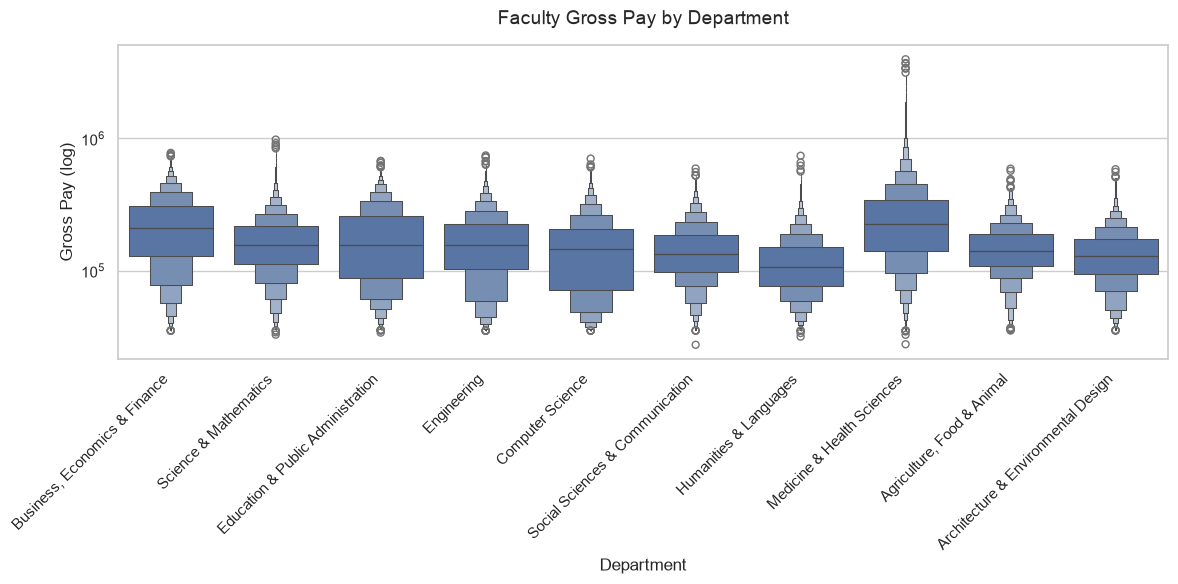

In [10]:
pay_by_salary = duckdb.sql("""
SELECT gross_pay, department
FROM faculty_salaries
""").pl()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

sns.boxenplot(
    data=pay_by_salary, 
    x="department",
    y='gross_pay',
    log_scale=True
)

plt.title("Faculty Gross Pay by Department", fontsize=14, pad=15)
plt.xlabel("Department", fontsize=12)
plt.ylabel("Gross Pay (log)", fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()